# RL Experiment Plots

Visualize training metrics from RL experiments across three settings:
- `real_world`
- `simulation`
- `simulation_with_real_world_input`

Metrics: `ep_len_mean`, `ep_rew_mean`, `top_score`

In [1]:
import sys
from pathlib import Path
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

root_dir = Path("..").resolve()
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import plot_functions
importlib.reload(plot_functions)
from plot_functions import plot_learning_curves

import style
importlib.reload(style)
from style import MatplotlibStyle

mpl_style = MatplotlibStyle()
mpl_style.apply()

In [2]:
def read_rl_csv(metric: str, key: str, base_dir: str = ".") -> pd.DataFrame:
    """
    Read an RL training CSV file by metric folder and file key.

    Args:
        metric:   subfolder name, e.g. "ep_len_mean", "ep_rew_mean", "top_score"
        key:      file stem, e.g. "real_world", "simulation",
                  "simulation_with_real_world_input"
        base_dir: root directory that contains the metric folders (default: ".")

    Returns:
        DataFrame with columns "Step" (x-axis) and "Value" (y-axis).
    """
    path = Path(base_dir) / metric / f"{key}.csv"
    df = pd.read_csv(path)
    return df[["Step", "Value"]].reset_index(drop=True)


def load_hns_scores(files_dict: dict, random_score: float, human_score: float) -> dict:
    """
    Load episode-score arrays from .npz files and convert to Human Normalized Score.

    Args:
        files_dict:   dict mapping label -> path to .npz file containing key 'array'.
        random_score: random-agent baseline score for the game.
        human_score:  human reference score for the game.

    Returns:
        dict mapping label -> 1-D numpy array of HNS values.
    """
    hns = {}
    for label, path in files_dict.items():
        raw = np.load(path)['array'].astype(float)
        hns[label] = (raw - random_score) / (human_score - random_score)
    return hns


In [3]:
from scipy.stats import bootstrap as _scipy_bootstrap


# ── Helper statistics ────────────────────────────────────────────────────────
def _iqm(x):
    """Interquartile Mean: mean of scores in the [Q25, Q75] range."""
    q25, q75 = np.percentile(x, [25, 75])
    return np.mean(x[(x >= q25) & (x <= q75)])


def _bootstrap_ci(data, stat_fn, n_resamples=10_000, ci=0.95, seed=0):
    """Return (point_estimate, ci_low, ci_high) via percentile bootstrap."""
    result = _scipy_bootstrap(
        (data,), stat_fn,
        n_resamples=n_resamples,
        confidence_level=ci,
        method='percentile',
        random_state=seed,
    )
    return stat_fn(data), result.confidence_interval.low, result.confidence_interval.high


# ── Plotting function ────────────────────────────────────────────────────────
def plot_interval_estimates(
    hns_scores,
    metric='Median',
    system_order=None,
    colours=None,
    figsize=(6.0, 2.6),
    bar_height=0.45,
    n_resamples=10_000,
    ci=0.95,
    save_path=None,
    dpi=800,
    fontsize_title=None,
    fontsize_label=None,
    fontsize_tick=None,
):
    """
    Plot a single interval-estimate bar chart for one statistic (Median / IQM / Mean).
    Font sizes fall back to rcParams values when not explicitly provided.

    Args:
        hns_scores:    dict mapping system label -> 1-D numpy array of HNS values.
        metric:        statistic to display: 'Median', 'IQM', or 'Mean'.
        system_order:  list of labels in display order (top to bottom).
                       Defaults to hns_scores.keys().
        colours:       dict mapping label -> colour string. Defaults to built-in palette.
        figsize:       figure size (width, height) in inches.
        bar_height:    height of each CI bar (0–1).
        n_resamples:   bootstrap resamples for CI estimation.
        ci:            confidence level, e.g. 0.95 for 95% CI.
        save_path:     if given, saves figure as <save_path>.pdf.
        dpi:           resolution for saved figure.
        fontsize_title: title font size (default: rcParams axes.titlesize).
        fontsize_label: x-axis label font size (default: rcParams axes.labelsize).
        fontsize_tick:  tick label font size (default: rcParams xtick.labelsize).
    """
    _STAT_FNS = {'Median': np.median, 'IQM': _iqm, 'Mean': np.mean}
    if metric not in _STAT_FNS:
        raise ValueError(f"metric must be one of {list(_STAT_FNS.keys())}, got '{metric}'")
    stat_fn = _STAT_FNS[metric]

    _title_fs = fontsize_title or plt.rcParams.get("axes.titlesize",  14)
    _label_fs = fontsize_label or plt.rcParams.get("axes.labelsize",  13)
    _tick_fs  = fontsize_tick  or plt.rcParams.get("xtick.labelsize", 11)

    _DEFAULT_COLOURS = {
        'simulation':        '#2BAAAB',
        'real world input':  '#E8A817',
        'real world system': '#3A88C5',
    }
    if colours is None:
        colours = _DEFAULT_COLOURS
        color_palette='colorblind'
        color_palette = sns.color_palette(color_palette, n_colors=len(hns_scores.keys()))
        colours = dict(zip(hns_scores.keys(), color_palette))
    if system_order is None:
        system_order = list(hns_scores.keys())

    fig, ax = plt.subplots(figsize=figsize)

    for yi, label in enumerate(system_order):
        data = hns_scores[label]
        pt, lo, hi = _bootstrap_ci(data, stat_fn, n_resamples=n_resamples, ci=ci)
        color = colours.get(label, 'steelblue')

        ax.barh(yi, hi - lo, left=lo, height=bar_height,
                color=color, alpha=0.85, linewidth=0)
        ax.plot([pt, pt], [yi - bar_height / 2, yi + bar_height / 2],
                color='black', linewidth=1.8, solid_capstyle='round')

    ax.set_yticks(range(len(system_order)))
    ax.set_yticklabels(system_order, fontsize=_tick_fs)
    ax.set_xlabel('Human Normalized Score', fontsize=_label_fs)
    ax.set_title(metric, fontsize=_title_fs, pad=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='y', length=0)
    ax.tick_params(axis='x', labelsize=_tick_fs)
    ax.grid(axis='x', linestyle='--', linewidth=0.6, alpha=0.5)

    if save_path:
        fig.savefig(f'{save_path}.png', dpi=dpi, bbox_inches='tight')
    fig.tight_layout()
    plt.show()


In [4]:
def plot_rl_curves(
    data_dict,
    colors=None,
    legend_map=None,
    title="RL Learning Curves",
    x_label="Step",
    y_label="Value",
    y_lim=None,
    figsize=(10, 6),
    window_size=10,
    is_legend=True,
    save_path=None,
    plot_raw=True,
    raw_alpha=0.35,
    raw_linewidth=0.7,
    smooth_linewidth=2,
    dpi=800,
    fontsize_title=None,
    fontsize_label=None,
    fontsize_legend=None,
    fontsize_tick=None,
    skip_color = 0,
):
    """
    Plot RL training curves with optional rolling-average smoothing.
    Uses MatplotlibStyle settings (font, colors, tick sizes) applied globally.
    Font sizes fall back to rcParams values when not explicitly provided.

    Args:
        data_dict:       dict mapping key -> DataFrame with "Step" and "Value" columns.
        colors:          list of line colors; if None, uses the style's prop_cycle colors.
        legend_map:      dict mapping key -> display label.
        y_lim:           (min, max) for y-axis, or None for auto.
        window_size:     rolling-average window (1 = no smoothing).
        save_path:       if given, saves figure as <save_path>.pdf.
        plot_raw:        overlay raw dashed trace under the smoothed line.
        fontsize_title:  title font size (default: rcParams axes.titlesize).
        fontsize_label:  x/y axis label font size (default: rcParams axes.labelsize).
        fontsize_legend: legend font size (default: rcParams legend.fontsize).
        fontsize_tick:   tick label font size (default: rcParams xtick/ytick.labelsize).
    """
    # Resolve font sizes from rcParams if not provided
    _title_fs  = fontsize_title  or plt.rcParams.get("axes.titlesize",  20)
    _label_fs  = fontsize_label  or plt.rcParams.get("axes.labelsize",  24)
    _legend_fs = fontsize_legend or plt.rcParams.get("legend.fontsize", 20)
    _tick_fs   = fontsize_tick   or plt.rcParams.get("xtick.labelsize", 20)

    # Resolve colors: use provided list, style prop_cycle, or a safe fallback
    if colors is None:
        prop_cycle = plt.rcParams.get("axes.prop_cycle", None)
        colors = [c["color"] for c in prop_cycle] if prop_cycle else \
                 ["red", "green", "blue", "orange", "purple", "brown"]
        color_palette='colorblind'
        # color_palette = sns.color_palette(color_palette, n_colors=len(data_dict))
        color_palette = sns.color_palette(color_palette, n_colors=len(data_dict)+skip_color)
        colors = dict(zip(data_dict, color_palette))
        print(colors)
    if len(colors) < len(data_dict):
        colors = [colors[i % len(colors)] for i in range(len(data_dict))]
        color_palette='colorblind'
        color_palette = sns.color_palette(color_palette, n_colors=len(data_dict))
        colors = dict(zip(data_dict, color_palette))
    fig, ax = plt.subplots(figsize=figsize)

    for idx, (key, df) in enumerate(data_dict.items()):
        label = legend_map.get(key, str(key)) if legend_map else str(key)
        steps = df["Step"].values
        values = df["Value"].values
        print(f"key: {key}")
        color = colors[key]
        # color = colors[idx]

        if plot_raw:
            ax.plot(steps, values, linestyle="dashed", linewidth=raw_linewidth,
                    alpha=raw_alpha, color=color)

        if len(values) >= window_size:
            smoothed = pd.Series(values).rolling(window=window_size, min_periods=1).mean().values
            ax.plot(steps, smoothed, color=color, linewidth=smooth_linewidth, label=label)
        else:
            ax.plot(steps, values, color=color, linewidth=smooth_linewidth, label=label)

    # handles, labels = ax.get_legend_handles_labels()
    # ax.legend(shadow=True, fontsize='x-large', reverse=True)
    if y_lim is not None:
        ax.set_ylim(y_lim)
    ax.set_title(title, fontsize=_title_fs)
    ax.set_xlabel(x_label, fontsize=_label_fs)
    ax.set_ylabel(y_label, fontsize=_label_fs)
    ax.tick_params(axis="x", labelsize=_tick_fs)
    ax.tick_params(axis="y", labelsize=_tick_fs)
    if is_legend:
        ax.legend(fontsize=_legend_fs, reverse=True)
    if save_path:
        fig.savefig(f"{save_path}.png", dpi=dpi, bbox_inches="tight")
    fig.tight_layout()
    plt.show()

## Episode Length Mean (`ep_len_mean`)

{'real_world': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), 'simulation_with_real_world_input': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), 'simulation': (0.00784313725490196, 0.6196078431372549, 0.45098039215686275)}
key: real_world
key: simulation_with_real_world_input
key: simulation


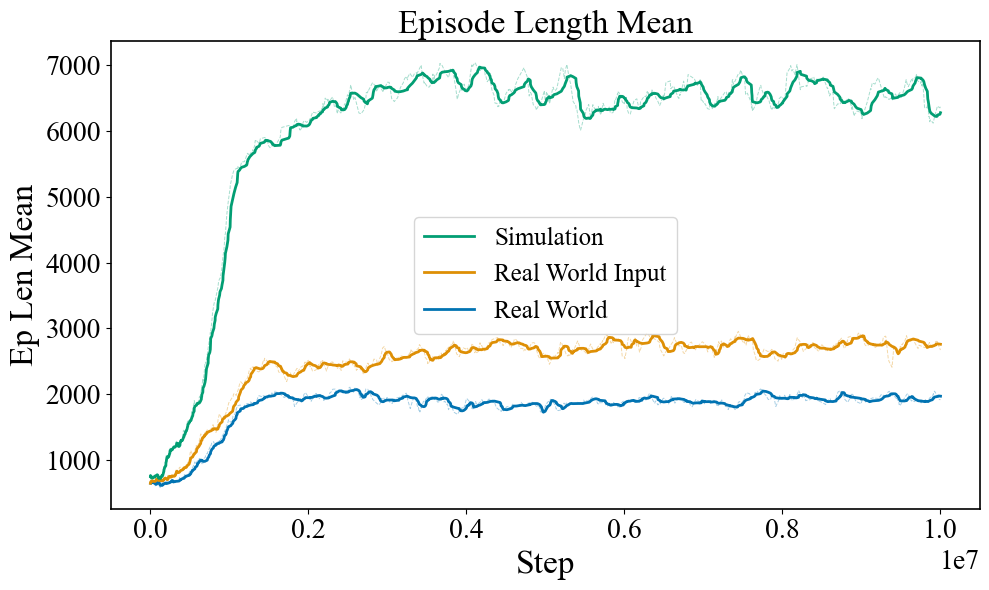

In [5]:
# keys = ["simulation", "simulation_with_real_world_input", "real_world"]
keys = ["real_world", "simulation_with_real_world_input", "simulation"]
legend_map = {
    "real_world": "Real World",
    "simulation_with_real_world_input": "Real World Input",
    "simulation": "Simulation",
}

data_ep_len = {key: read_rl_csv("ep_len_mean", key) for key in keys}

plot_rl_curves(
    data_ep_len,
    legend_map=legend_map,
    title="Episode Length Mean",
    x_label="Step",
    y_label="Ep Len Mean",
    figsize=(10, 6),
    window_size=10,
    save_path='three_system_len',
    is_legend=True,
)

## Episode Reward Mean (`ep_rew_mean`)

{'real_world': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), 'simulation_with_real_world_input': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), 'simulation': (0.00784313725490196, 0.6196078431372549, 0.45098039215686275)}
key: real_world
key: simulation_with_real_world_input
key: simulation


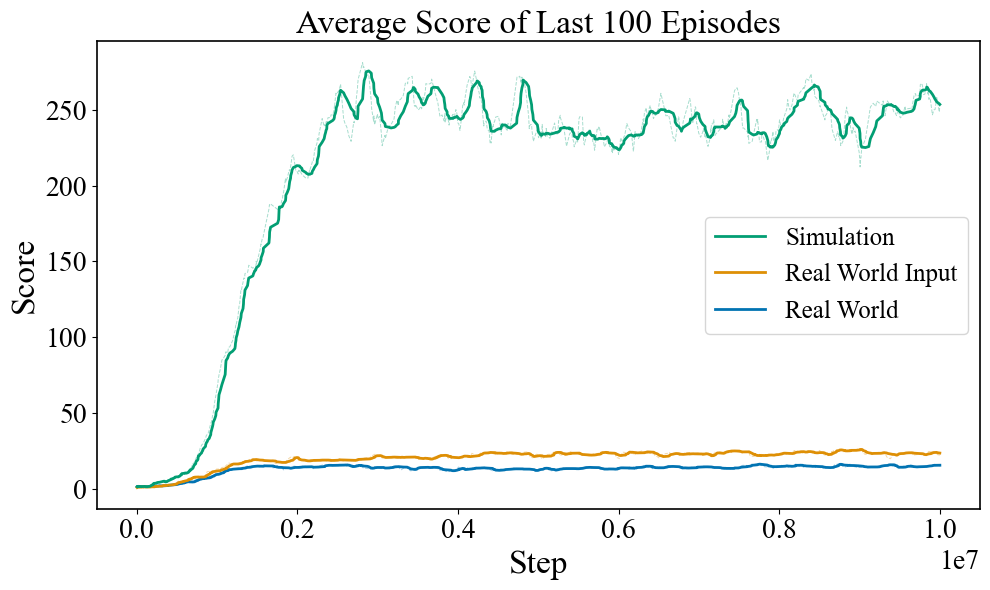

In [6]:
data_ep_rew = {key: read_rl_csv("ep_rew_mean", key) for key in keys}

plot_rl_curves(
    data_ep_rew,
    legend_map=legend_map,
    title="Average Score of Last 100 Episodes",
    x_label="Step",
    y_label="Score",
    figsize=(10, 6),
    window_size=10,
    save_path='three_system',
    is_legend=True,
)

{'real_world': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), 'simulation_with_real_world_input': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549)}
key: real_world
key: simulation_with_real_world_input


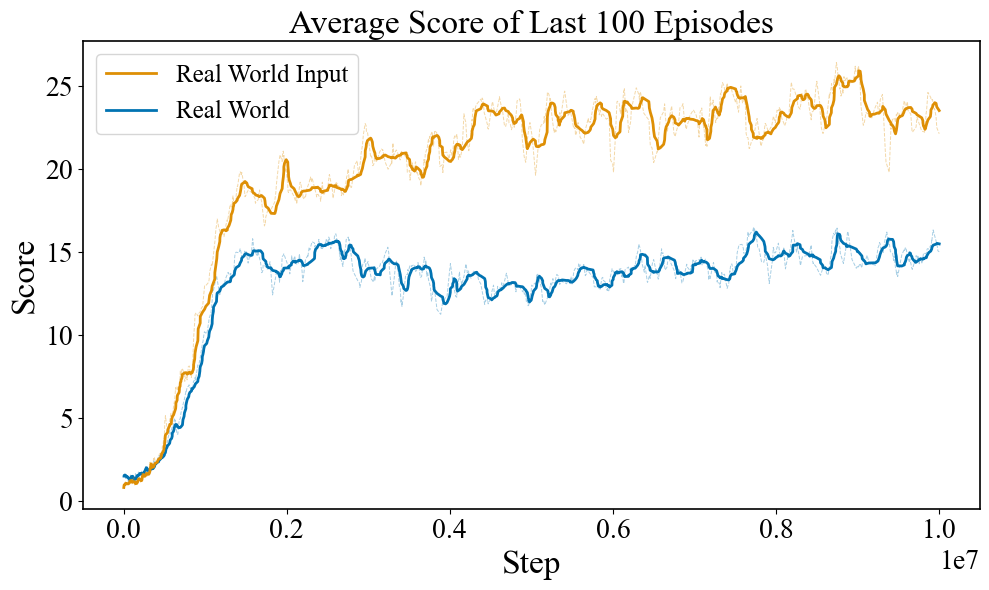

In [7]:
keys = ["real_world", "simulation_with_real_world_input", "simulation"]
legend_map = {
    "real_world": "Real World",
    "simulation_with_real_world_input": "Real World Input",
    "simulation": "Simulation",
}

keys = ["real_world", "simulation_with_real_world_input"]
data_ep_rew = {key: read_rl_csv("ep_rew_mean", key) for key in keys}

plot_rl_curves(
    data_ep_rew,
    legend_map=legend_map,
    # colors=["green", "dodgerblue"],
    title="Average Score of Last 100 Episodes",
    x_label="Step",
    y_label="Score",
    figsize=(10, 6),
    window_size=10,
    save_path='two_system',
    is_legend=True,
    skip_color=1,
)

## Top Score (`top_score`)

{'real_world': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), 'simulation_with_real_world_input': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549)}
key: real_world
key: simulation_with_real_world_input


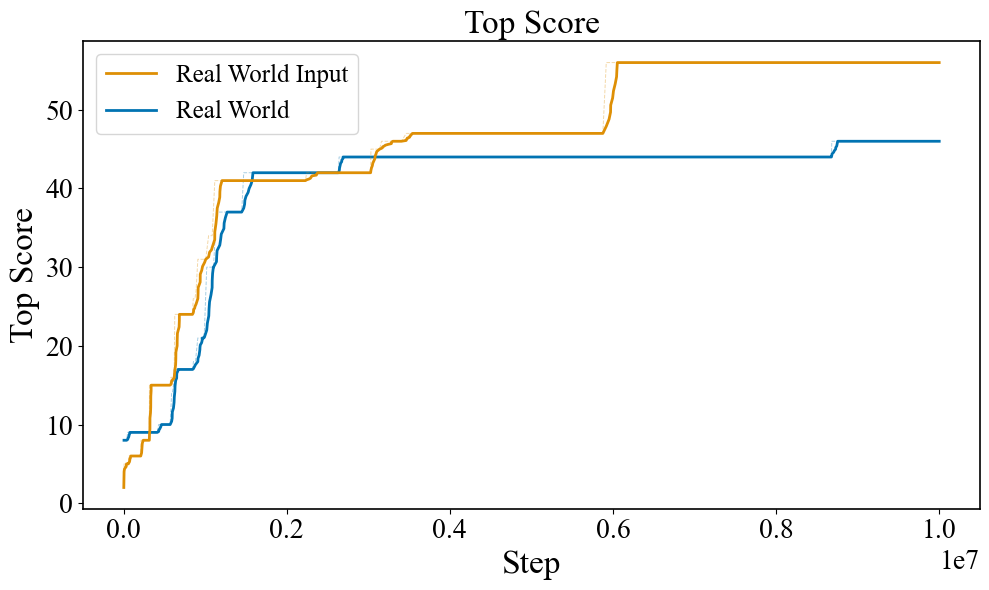

In [8]:
data_top_score = {key: read_rl_csv("top_score", key) for key in keys}

plot_rl_curves(
    data_top_score,
    legend_map=legend_map,
    title="Top Score",
    x_label="Step",
    y_label="Top Score",
    figsize=(10, 6),
    window_size=10,
    is_legend=True,
)

## Time Cost Comparison (Bar Chart)

Compare the **total wall-clock time consumed** by each setting across equal-length step intervals.

In [9]:
def read_rl_csv_full(metric: str, key: str, base_dir: str = ".") -> pd.DataFrame:
    """Read RL CSV with Wall time, Step, Value columns."""
    path = Path(base_dir) / metric / f"{key}.csv"
    df = pd.read_csv(path)
    return df[["Wall time", "Step", "Value"]].reset_index(drop=True)


def plot_time_cost_bar(
    metric: str = "ep_len_mean",
    keys: list = None,
    legend_map: dict = None,
    base_dir: str = ".",
    title: str = "Total Time Cost Comparison",
    # x_label: str = "Time Cost (s)",
    x_label: str = " ",
    y_label: str = " ",
    figsize: tuple = (8, 4),
    colors: list = None,
    save_path: str = None,
    dpi: int = 800,
    fontsize_title=None,
    fontsize_label=None,
    fontsize_tick=None,
    horizontal = True,
):
    """
    Plot a horizontal bar chart of total wall-clock time cost per setting.

    The total time is computed as:  max(Wall time) - min(Wall time).

    Args:
        metric:         which metric folder to read (only Wall time is used).
        keys:           list of file stems (settings).
        legend_map:     dict mapping key -> display label.
        base_dir:       root directory containing metric sub-folders.
        title:          chart title.
        x_label:        x-axis label.
        y_label:        y-axis label.
        figsize:        figure size (width, height) in inches.
        colors:         list of bar colours; if None, uses the style prop_cycle.
        save_path:      if given, saves the figure as <save_path>.pdf.
        dpi:            resolution for saved figure.
        fontsize_title: title font size (default: rcParams axes.titlesize).
        fontsize_label: axis label font size (default: rcParams axes.labelsize).
        fontsize_tick:  tick label font size (default: rcParams xtick.labelsize).
    """
    if keys is None:
        if horizontal:
            keys=["real_world", "simulation_with_real_world_input", "simulation"]
        else:
            keys=["simulation", "simulation_with_real_world_input", "real_world"]
            # keys=["real_world", "simulation_with_real_world_input", "simulation"]
        # keys = ["real_world", "simulation", "simulation_with_real_world_input"]
        # keys = ["real_world", "simulation_with_real_world_input", "simulation"]

    _title_fs = fontsize_title or plt.rcParams.get("axes.titlesize",  14)
    _label_fs = fontsize_label or plt.rcParams.get("axes.labelsize",  12)
    _tick_fs  = fontsize_tick  or plt.rcParams.get("xtick.labelsize", 10)

    # Load data and compute total wall-clock time per key
    total_times = {}
    for key in keys:
        print("key: ", key)
        df = read_rl_csv_full(metric, key, base_dir)
        total_times[key] = (df["Wall time"].max() - df["Wall time"].min())/3600/24

    # Resolve colors
    if colors is None:
        prop_cycle = plt.rcParams.get("axes.prop_cycle", None)
        # color_palette = sns.color_palette(color_palette, n_colors=len(algorithms)+1)
        colors = [c["color"] for c in prop_cycle] if prop_cycle else \
                 ["red", "green", "blue", "orange", "purple"]
        color_palette='colorblind'
        color_palette = sns.color_palette(color_palette, n_colors=len(keys))
        colors = dict(zip(keys, color_palette))
        print(colors)
    labels = [legend_map.get(k, k) if legend_map else k for k in keys]
    print(labels)

    values = [total_times[k] for k in keys]
    print(values)
    # bar_colors = [colors[i % len(colors)] for i in range(len(keys))]
    if horizontal:
        bar_colors = [colors[key] for key in keys]
    else:
        bar_colors = [colors[key] for key in keys][::-1]
    print(f"bar_colors: {bar_colors}")

    if horizontal:
        figsize = (5, 5)
        x_label = "Days"
    else:
        figsize = (5, 5)
        y_label = "Days"
    fig, ax = plt.subplots(figsize=figsize)
    # x = range(len(labels))
    if horizontal:
        bars = ax.barh(labels, values, height = 0.7, color=bar_colors, edgecolor="white", linewidth=0.5)
        # bars = ax.barh(labels, values, color=colors, edgecolor="white", linewidth=0.5)
        ax.set_xlim(right=max(values) * 1.1)
    else:
        bars = ax.bar(labels, values, width =0.7, color=bar_colors)
        ax.bar_label(bars, padding=3, fontsize=18, fmt="%.1f")
        ax.set_ylim(top=max(values) * 1.15)
        # ax.set_xticklabels(labels, rotation=90)
        # plt.xticks(rotation=90) 



    # ax.set_title(title, fontsize=_title_fs, pad=8)
    ax.set_xlabel(x_label, fontsize=_label_fs)
    ax.set_ylabel(y_label, fontsize=_label_fs)
    ax.tick_params(axis="x", labelsize=_tick_fs)
    ax.tick_params(axis="y", labelsize=_tick_fs)
    

    if save_path:
        fig.savefig(f"{save_path}.pdf", dpi=dpi, bbox_inches="tight")
    fig.tight_layout()
    plt.show()


key:  simulation
key:  simulation_with_real_world_input
key:  real_world
{'simulation': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), 'simulation_with_real_world_input': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), 'real_world': (0.00784313725490196, 0.6196078431372549, 0.45098039215686275)}
['Sim', 'Real Input', 'Real']
[np.float64(1.4435714819282293), np.float64(8.859758258094942), np.float64(19.995359591866535)]
bar_colors: [(0.00784313725490196, 0.6196078431372549, 0.45098039215686275), (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), (0.00392156862745098, 0.45098039215686275, 0.6980392156862745)]


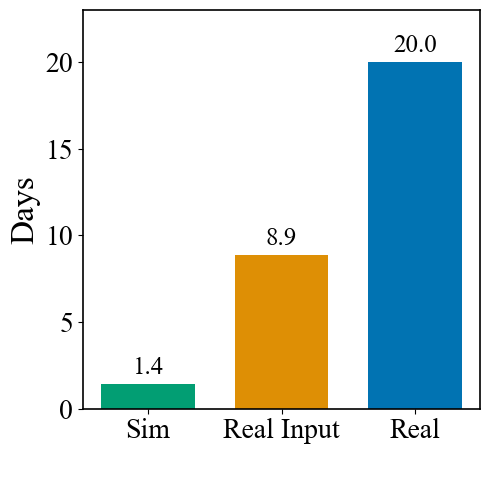

In [33]:
legend_map = {
    "real_world": "Real",
    "simulation_with_real_world_input": "Real Input",
    "simulation": "Sim",
}

plot_time_cost_bar(
    metric="ep_len_mean",
    # keys=["real_world", "simulation_with_real_world_input", "simulation"],
    legend_map=legend_map,
    base_dir=".",
    # colors=["red", "green", "dodgerblue"],
    title="Training Time",
    # title="Total Training Time for 10 Million Steps",
    # y_label="Days",
    # figsize=(4, 8),
    save_path="time_cost_bar",
    horizontal = False,
)

In [11]:
def plot_maximum_score_bar(
    metric: str = "ep_rew_mean",
    keys: list = None,
    legend_map: dict = None,
    base_dir: str = ".",
    title: str = "Total Time Cost Comparison",
    # x_label: str = "Time Cost (s)",
    x_label: str = " ",
    y_label: str = " ",
    figsize: tuple = (8, 4),
    colors: list = None,
    save_path: str = None,
    dpi: int = 800,
    fontsize_title=None,
    fontsize_label=None,
    fontsize_tick=None,
    horizontal = True,
):
    """
    Plot a horizontal bar chart of total wall-clock time cost per setting.

    The total time is computed as:  max(Wall time) - min(Wall time).

    Args:
        metric:         which metric folder to read (only Wall time is used).
        keys:           list of file stems (settings).
        legend_map:     dict mapping key -> display label.
        base_dir:       root directory containing metric sub-folders.
        title:          chart title.
        x_label:        x-axis label.
        y_label:        y-axis label.
        figsize:        figure size (width, height) in inches.
        colors:         list of bar colours; if None, uses the style prop_cycle.
        save_path:      if given, saves the figure as <save_path>.pdf.
        dpi:            resolution for saved figure.
        fontsize_title: title font size (default: rcParams axes.titlesize).
        fontsize_label: axis label font size (default: rcParams axes.labelsize).
        fontsize_tick:  tick label font size (default: rcParams xtick.labelsize).
    """
    if keys is None:
        if horizontal:
            keys=["real_world", "simulation_with_real_world_input", "simulation"]
        else:
            keys=["simulation", "simulation_with_real_world_input", "real_world"]
        # keys = ["real_world", "simulation", "simulation_with_real_world_input"]
        # keys = ["real_world", "simulation_with_real_world_input", "simulation"]

    _title_fs = fontsize_title or plt.rcParams.get("axes.titlesize",  14)
    _label_fs = fontsize_label or plt.rcParams.get("axes.labelsize",  12)
    _tick_fs  = fontsize_tick  or plt.rcParams.get("xtick.labelsize", 10)

    # Load data and compute total wall-clock time per key
    max_mean_score = {}
    for key in keys:
        print("key: ", key)
        df = read_rl_csv_full(metric, key, base_dir)
        max_mean_score[key] = df["Value"].max()

    # Resolve colors
    if colors is None:
        prop_cycle = plt.rcParams.get("axes.prop_cycle", None)
        # color_palette = sns.color_palette(color_palette, n_colors=len(algorithms)+1)
        colors = [c["color"] for c in prop_cycle] if prop_cycle else \
                 ["red", "green", "blue", "orange", "purple"]
        color_palette='colorblind'
        color_palette = sns.color_palette(color_palette, n_colors=len(keys))
        colors = dict(zip(keys, color_palette))
        print(colors)
    labels = [legend_map.get(k, k) if legend_map else k for k in keys]
    print(labels)
    values = [max_mean_score[k] for k in keys]
    # bar_colors = [colors[i % len(colors)] for i in range(len(keys))]
    bar_colors = [colors[key] for key in keys][::-1]
    print(f"bar_colors: {bar_colors}")

    if horizontal:
        figsize = (8, 4)
        x_label = "Scores"
    else:
        figsize = (5, 5)
        y_label = "Scores"
    fig, ax = plt.subplots(figsize=figsize)
    # x = range(len(labels))
    if horizontal:
        bars = ax.barh(labels, values, color=bar_colors, edgecolor="white", linewidth=0.5)
        # bars = ax.barh(labels, values, color=colors, edgecolor="white", linewidth=0.5)
        ax.set_xlim(right=max(values) * 1.1)
    else:
        bars = ax.bar(labels, values, width=0.7, color=bar_colors)
        ax.bar_label(bars, padding=3, fontsize=18, fmt="%.1f")
        ax.set_ylim(top=max(values) * 1.1)
        # ax.set_xticklabels(labels, rotation=90)
        # plt.xticks(rotation=90)



    # ax.set_title(title, fontsize=_title_fs, pad=8)
    ax.set_xlabel(x_label, fontsize=_label_fs)
    ax.set_ylabel(y_label, fontsize=_label_fs)
    ax.tick_params(axis="x", labelsize=_tick_fs)
    ax.tick_params(axis="y", labelsize=_tick_fs)
    

    if save_path:
        fig.savefig(f"{save_path}.pdf", dpi=dpi, bbox_inches="tight")
    fig.tight_layout()
    plt.show()

key:  simulation
key:  simulation_with_real_world_input
key:  real_world
{'simulation': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), 'simulation_with_real_world_input': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), 'real_world': (0.00784313725490196, 0.6196078431372549, 0.45098039215686275)}
['Sim', 'Real Input', 'Real']
bar_colors: [(0.00784313725490196, 0.6196078431372549, 0.45098039215686275), (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), (0.00392156862745098, 0.45098039215686275, 0.6980392156862745)]


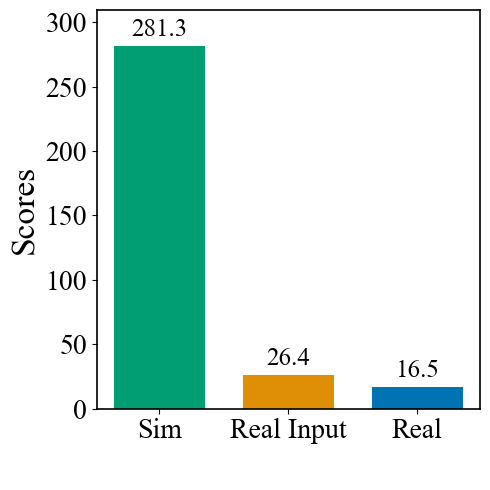

In [12]:

plot_maximum_score_bar(
    metric="ep_rew_mean",
    # keys=["real_world", "simulation_with_real_world_input", "simulation"],
    legend_map=legend_map,
    base_dir=".",
    # colors=["red", "green", "dodgerblue"],
    title="Maximum Score",
    # y_label="Days",
    # figsize=(4, 8),
    save_path="max_score_bar",
    horizontal = False,
)

## Three Systems Comparison — Interval Estimates (Median / IQM / Mean)

In [13]:
# Breakout: random ≈ 1.7, human ≈ 30.5
RANDOM_SCORE = 1.7
HUMAN_SCORE  = 30.5

_3systems_files = {
    'real world system': './datalogs/3systems/breakout-data-dqn-model-r10_000_000.npz',
    'real world input':  './datalogs/3systems/breakout-data-dqn-model-c10_000_000.npz',
    'simulation':        './datalogs/3systems/breakout-data-dqn-model-s10_000_000.npz',
}

hns_scores = load_hns_scores(_3systems_files, RANDOM_SCORE, HUMAN_SCORE)

for lbl, arr in hns_scores.items():
    print(f"{lbl:25s}: n={len(arr):3d}  mean={arr.mean():.3f}  median={np.median(arr):.3f}")

real world system        : n=100  mean=0.426  median=0.410
real world input         : n=101  mean=0.752  median=0.705
simulation               : n=101  mean=8.389  median=9.212


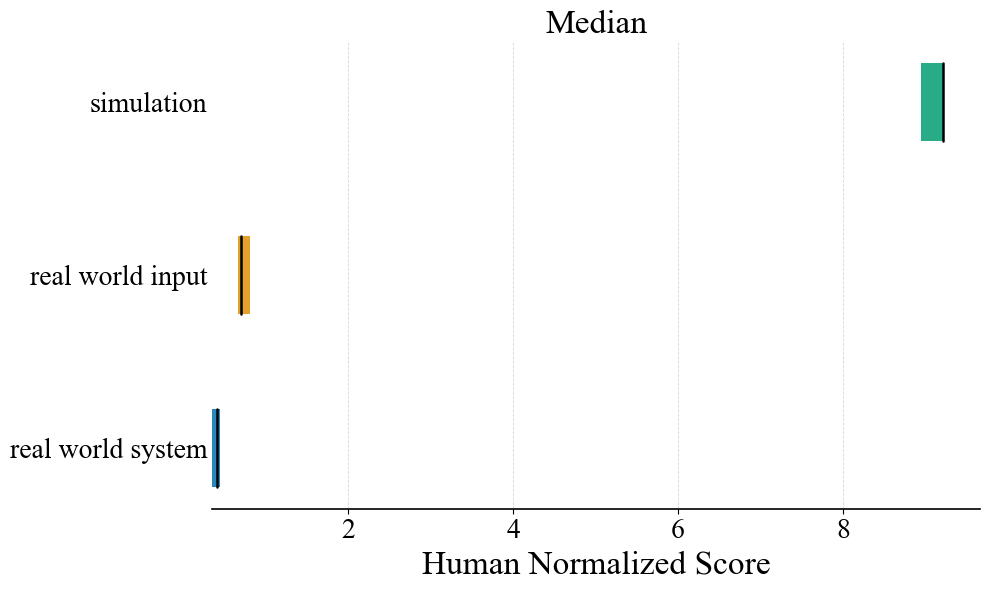

In [14]:
# SYSTEM_ORDER = ['simulation', 'real world input', 'real world system']
SYSTEM_ORDER = ['real world system', 'real world input', 'simulation']
legend_map = {
    "real world system": "R/W",
    "real world input": "R/I",
    "simulation": "Sim",
}

# legend_map = {
#     "real_world": "R/W",
#     "simulation_with_real_world_input": "R/I",
#     "simulation": "Sim",
# }
plot_interval_estimates(
    hns_scores,
    metric='Median',
    system_order=SYSTEM_ORDER,
    figsize=(10, 6),
    save_path='three_systems_median',
)


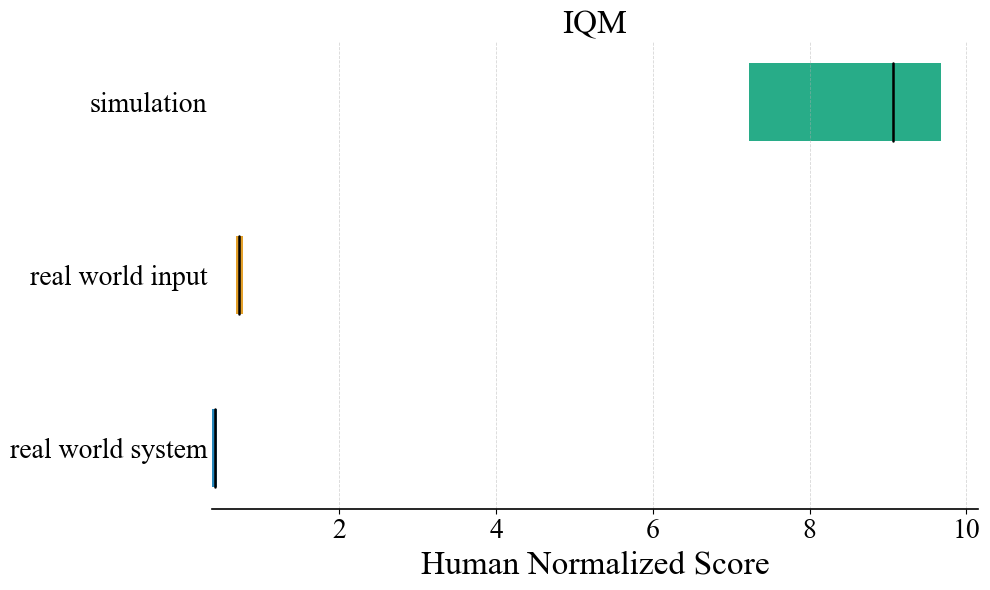

In [15]:
plot_interval_estimates(
    hns_scores,
    metric='IQM',
    system_order=SYSTEM_ORDER,
    figsize=(10, 6),
    save_path='three_systems_iqm',
)


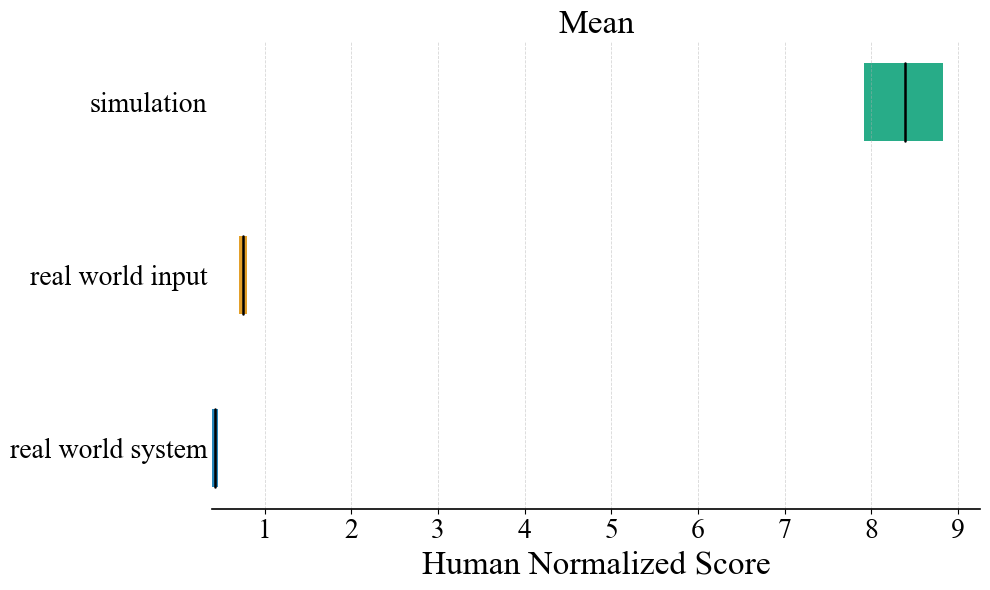

In [16]:
plot_interval_estimates(
    hns_scores,
    metric='Mean',
    system_order=SYSTEM_ORDER,
    figsize=(10, 6),
    save_path='three_systems_mean',
)


In [39]:
# ── Plotting function ────────────────────────────────────────────────────────
def plot_existing_data_interval_estimates(
    point_estimates,
    interval_estimates,
    metric='Median',
    legend_map=legend_map,
    system_order=None,
    colours=None,
    figsize=(6.0, 2.6),
    bar_height=0.45,
    n_resamples=10_000,
    ci=0.95,
    save_path=None,
    dpi=800,
    fontsize_title=None,
    fontsize_label=None,
    fontsize_tick=None,
):
    """
    Plot a single interval-estimate bar chart for one statistic (Median / IQM / Mean).
    Font sizes fall back to rcParams values when not explicitly provided.

    Args:
        hns_scores:    dict mapping system label -> 1-D numpy array of HNS values.
        metric:        statistic to display: 'Median', 'IQM', or 'Mean'.
        system_order:  list of labels in display order (top to bottom).
                       Defaults to hns_scores.keys().
        colours:       dict mapping label -> colour string. Defaults to built-in palette.
        figsize:       figure size (width, height) in inches.
        bar_height:    height of each CI bar (0–1).
        n_resamples:   bootstrap resamples for CI estimation.
        ci:            confidence level, e.g. 0.95 for 95% CI.
        save_path:     if given, saves figure as <save_path>.pdf.
        dpi:           resolution for saved figure.
        fontsize_title: title font size (default: rcParams axes.titlesize).
        fontsize_label: x-axis label font size (default: rcParams axes.labelsize).
        fontsize_tick:  tick label font size (default: rcParams xtick.labelsize).
    """
    _title_fs = fontsize_title or plt.rcParams.get("axes.titlesize",  22)
    _label_fs = fontsize_label or plt.rcParams.get("axes.labelsize",  22)
    _tick_fs  = fontsize_tick  or plt.rcParams.get("xtick.labelsize", 22)

    _DEFAULT_COLOURS = {
        'simulation':        '#2BAAAB',
        'real world input':  '#E8A817',
        'real world system': '#3A88C5',
    }
    if colours is None:
        colours = _DEFAULT_COLOURS
        color_palette='colorblind'
        color_palette = sns.color_palette(color_palette, n_colors=len(hns_scores.keys()))
        colours = dict(zip(hns_scores.keys(), color_palette))
    if system_order is None:
        system_order = list(hns_scores.keys())

    fig, ax = plt.subplots(figsize=figsize)

    for yi, label in enumerate(system_order):
        pt = point_estimates[label]
        lo, hi = interval_estimates[label]
        color = colours.get(label, 'steelblue')

        ax.barh(yi, hi - lo, left=lo, height=bar_height,
                color=color, alpha=0.85, linewidth=0)
        ax.plot([pt, pt], [yi - bar_height / 2, yi + bar_height / 2],
                color='black', linewidth=1.8, solid_capstyle='round')

    print("legend_map: ", legend_map)
    print("keys :", keys)

    labels = list(legend_map.values())
    print("labels: ", labels)
    ax.set_yticks(range(len(system_order)))
    # ax.set_yticklabels(system_order, fontsize=_tick_fs)
    ax.set_yticklabels(labels, fontsize=_tick_fs)
    # ax.set_xlabel('Human Normalized Score', fontsize=_label_fs)
    # ax.set_title(metric, fontsize=_title_fs, pad=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='y', length=0)
    ax.tick_params(axis='x', labelsize=_tick_fs)
    ax.grid(axis='x', linestyle='--', linewidth=0.6, alpha=0.5)

    if save_path:
        fig.savefig(f'{save_path}.pdf', dpi=dpi, bbox_inches='tight')
    fig.tight_layout()
    plt.show()


In [40]:
SYSTEM_ORDER = ['real world system', 'real world input', 'simulation']
legend_map = {
    "real world system": "R/W",
    "real world input": "R/I",
    "simulation": "Sim",
}

In [41]:
aggregate_scores = {
        "real world system": np.array([0.40972222, 0.41041667, 0.42638889, 0.57361111]), 
        "real world input": np.array([0.70486111, 0.72291667, 0.75      , 0.27517361]), "simulation": np.array([9.07291667, 9.07291667, 8.38055556, 0.        ])}
aggregate_score_cis = {
        "real world system": np.array([[0.35763889, 0.38055556, 0.39722222, 0.54375   ],
                                       [0.44444444, 0.44513889, 0.45625   , 0.60277778]]), 
        "real world input": np.array([[0.65277778, 0.67430556, 0.70451389, 0.23888889],
                                      [0.79166667, 0.77152778, 0.79791667, 0.31163194]]), 
        "simulation": np.array([[8.93402778, 8.73680556, 7.90347222, 0.        ],
                                [9.21180556, 9.29791667, 8.83333333, 0.        ]])}

In [42]:
aggregate_scores_median = {key: value[0:1] for key, value in aggregate_scores.items()}
aggregate_score_cis_median = {key: value[:, 0:1]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_median: type: {type(aggregate_scores_median)}, data: {aggregate_scores_median}")
print(f"aggregate_score_cis_median: type: {type(aggregate_score_cis_median)}, data: {aggregate_score_cis_median}")

aggregate_scores_median: type: <class 'dict'>, data: {'real world system': array([0.40972222]), 'real world input': array([0.70486111]), 'simulation': array([9.07291667])}
aggregate_score_cis_median: type: <class 'dict'>, data: {'real world system': array([[0.35763889],
       [0.44444444]]), 'real world input': array([[0.65277778],
       [0.79166667]]), 'simulation': array([[8.93402778],
       [9.21180556]])}


legend_map:  {'real world system': 'R/W', 'real world input': 'R/I', 'simulation': 'Sim'}
keys : ['real_world', 'simulation_with_real_world_input']
labels:  ['R/W', 'R/I', 'Sim']


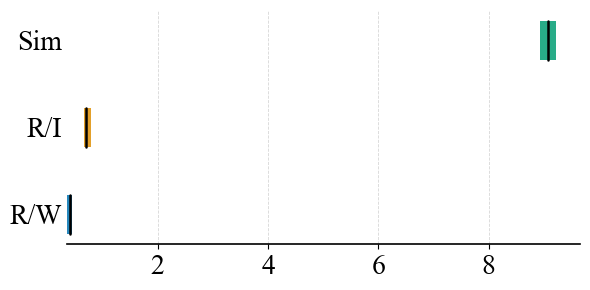

In [43]:
plot_existing_data_interval_estimates(
    aggregate_scores_median,
    aggregate_score_cis_median,
    metric='Median',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='three_systems_median',
)

In [44]:
aggregate_scores_iqm = {key: value[1:2] for key, value in aggregate_scores.items()}
aggregate_score_cis_iqm = {key: value[:, 1:2]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_iqm: type: {type(aggregate_scores_iqm)}, data: {aggregate_scores_iqm}")
print(f"aggregate_score_cis_iqm: type: {type(aggregate_score_cis_iqm)}, data: {aggregate_score_cis_iqm}")

aggregate_scores_iqm: type: <class 'dict'>, data: {'real world system': array([0.41041667]), 'real world input': array([0.72291667]), 'simulation': array([9.07291667])}
aggregate_score_cis_iqm: type: <class 'dict'>, data: {'real world system': array([[0.38055556],
       [0.44513889]]), 'real world input': array([[0.67430556],
       [0.77152778]]), 'simulation': array([[8.73680556],
       [9.29791667]])}


legend_map:  {'real world system': 'R/W', 'real world input': 'R/I', 'simulation': 'Sim'}
keys : ['real_world', 'simulation_with_real_world_input']
labels:  ['R/W', 'R/I', 'Sim']


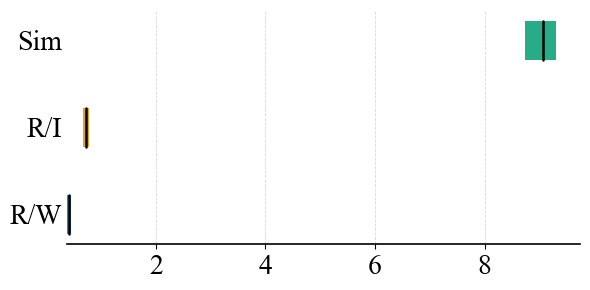

In [45]:
plot_existing_data_interval_estimates(
    aggregate_scores_iqm,
    aggregate_score_cis_iqm,
    metric='IQM',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='three_systems_iqm',
)

In [46]:
aggregate_scores_mean = {key: value[2:3] for key, value in aggregate_scores.items()}
aggregate_score_cis_mean = {key: value[:, 2:3]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_mean: type: {type(aggregate_scores_mean)}, data: {aggregate_scores_mean}")
print(f"aggregate_score_cis_mean: type: {type(aggregate_score_cis_mean)}, data: {aggregate_score_cis_mean}")

aggregate_scores_mean: type: <class 'dict'>, data: {'real world system': array([0.42638889]), 'real world input': array([0.75]), 'simulation': array([8.38055556])}
aggregate_score_cis_mean: type: <class 'dict'>, data: {'real world system': array([[0.39722222],
       [0.45625   ]]), 'real world input': array([[0.70451389],
       [0.79791667]]), 'simulation': array([[7.90347222],
       [8.83333333]])}


legend_map:  {'real world system': 'R/W', 'real world input': 'R/I', 'simulation': 'Sim'}
keys : ['real_world', 'simulation_with_real_world_input']
labels:  ['R/W', 'R/I', 'Sim']


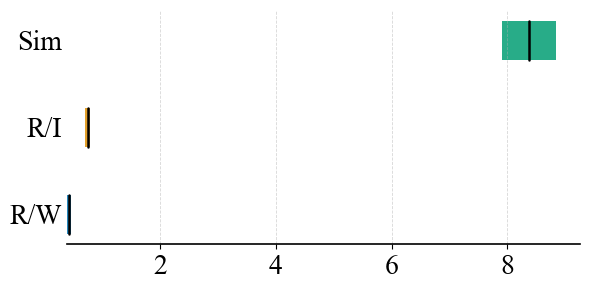

In [47]:
plot_existing_data_interval_estimates(
    aggregate_scores_mean,
    aggregate_score_cis_mean,
    metric='Mean',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='three_systems_mean',
)

In [48]:
aggregate_scores_optimality_gap = {key: value[3:4] for key, value in aggregate_scores.items()}
aggregate_score_cis_optimality_gap = {key: value[:, 3:4]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_optimality_gap: type: {type(aggregate_scores_optimality_gap)}, data: {aggregate_scores_optimality_gap}")
print(f"aggregate_score_cis_optimality_gap: type: {type(aggregate_score_cis_optimality_gap)}, data: {aggregate_score_cis_optimality_gap}")

aggregate_scores_optimality_gap: type: <class 'dict'>, data: {'real world system': array([0.57361111]), 'real world input': array([0.27517361]), 'simulation': array([0.])}
aggregate_score_cis_optimality_gap: type: <class 'dict'>, data: {'real world system': array([[0.54375   ],
       [0.60277778]]), 'real world input': array([[0.23888889],
       [0.31163194]]), 'simulation': array([[0.],
       [0.]])}


legend_map:  {'real world system': 'R/W', 'real world input': 'R/I', 'simulation': 'Sim'}
keys : ['real_world', 'simulation_with_real_world_input']
labels:  ['R/W', 'R/I', 'Sim']


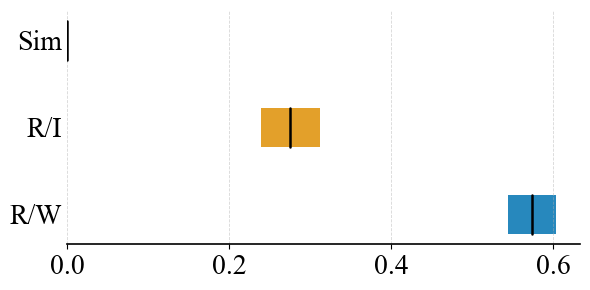

In [49]:
plot_existing_data_interval_estimates(
    aggregate_scores_optimality_gap,
    aggregate_score_cis_optimality_gap,
    metric='Optimality Gap',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='three_systems_optimality_gap',
)

In [51]:
aggregate_scores = {
        "real world input": np.array([0.70486111, 0.72291667, 0.75      , 0.27517361]), 
        "simulation": np.array([ 0.01041667, -0.00763889, -0.01111111,  1.01111111])}
aggregate_score_cis = {
        "real world input": np.array([[0.65277778, 0.67430556, 0.70451389, 0.23888889],
       [0.79166667, 0.77152778, 0.79791667, 0.31163194]]), 
        "simulation": np.array([[-0.02430556, -0.01944444, -0.01840278,  1.00381944],
       [ 0.01041667,  0.00138889, -0.00381944,  1.01840278]])}

In [52]:
print(f"aggregate_scores: type: {type(aggregate_scores)}, data: {aggregate_scores}")
print(f"aggregate_scores: type: {type(aggregate_score_cis)}, data: {aggregate_score_cis}")

aggregate_scores: type: <class 'dict'>, data: {'real world input': array([0.70486111, 0.72291667, 0.75      , 0.27517361]), 'simulation': array([ 0.01041667, -0.00763889, -0.01111111,  1.01111111])}
aggregate_scores: type: <class 'dict'>, data: {'real world input': array([[0.65277778, 0.67430556, 0.70451389, 0.23888889],
       [0.79166667, 0.77152778, 0.79791667, 0.31163194]]), 'simulation': array([[-0.02430556, -0.01944444, -0.01840278,  1.00381944],
       [ 0.01041667,  0.00138889, -0.00381944,  1.01840278]])}


In [53]:
aggregate_scores_median = {key: value[0:1] for key, value in aggregate_scores.items()}
aggregate_score_cis_median = {key: value[:, 0:1]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_median: type: {type(aggregate_scores_median)}, data: {aggregate_scores_median}")
print(f"aggregate_score_cis_median: type: {type(aggregate_score_cis_median)}, data: {aggregate_score_cis_median}")


aggregate_scores_median: type: <class 'dict'>, data: {'real world input': array([0.70486111]), 'simulation': array([0.01041667])}
aggregate_score_cis_median: type: <class 'dict'>, data: {'real world input': array([[0.65277778],
       [0.79166667]]), 'simulation': array([[-0.02430556],
       [ 0.01041667]])}


In [54]:
SYSTEM_ORDER = ['real world input', 'simulation']
legend_map = {
    "real world input": "R/I",
    "simulation": "Sim",
}

legend_map:  {'real world input': 'R/I', 'simulation': 'Sim'}
keys : ['real_world', 'simulation_with_real_world_input']
labels:  ['R/I', 'Sim']


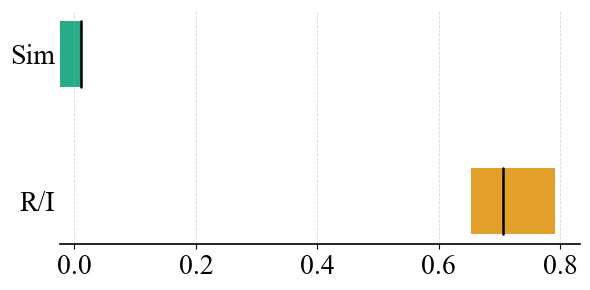

In [55]:
plot_existing_data_interval_estimates(
    aggregate_scores_median,
    aggregate_score_cis_median,
    metric='Median',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='two_systems_median',
)

In [56]:
aggregate_scores_iqm = {key: value[1:2] for key, value in aggregate_scores.items()}
aggregate_score_cis_iqm = {key: value[:, 1:2]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_iqm: type: {type(aggregate_scores_iqm)}, data: {aggregate_scores_iqm}")
print(f"aggregate_score_cis_iqm: type: {type(aggregate_score_cis_iqm)}, data: {aggregate_score_cis_iqm}")

aggregate_scores_iqm: type: <class 'dict'>, data: {'real world input': array([0.72291667]), 'simulation': array([-0.00763889])}
aggregate_score_cis_iqm: type: <class 'dict'>, data: {'real world input': array([[0.67430556],
       [0.77152778]]), 'simulation': array([[-0.01944444],
       [ 0.00138889]])}


legend_map:  {'real world input': 'R/I', 'simulation': 'Sim'}
keys : ['real_world', 'simulation_with_real_world_input']
labels:  ['R/I', 'Sim']


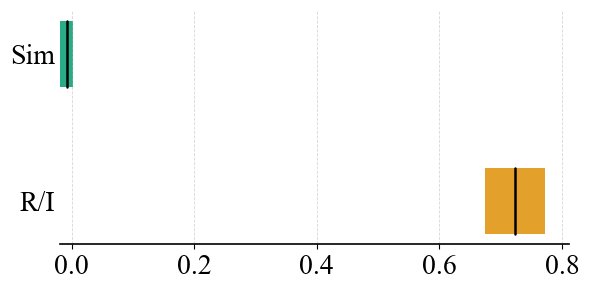

In [57]:
plot_existing_data_interval_estimates(
    aggregate_scores_iqm,
    aggregate_score_cis_iqm,
    metric='IQM',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='two_systems_iqm',
)

In [58]:
aggregate_scores_mean = {key: value[2:3] for key, value in aggregate_scores.items()}
aggregate_score_cis_mean = {key: value[:, 2:3]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_mean: type: {type(aggregate_scores_mean)}, data: {aggregate_scores_mean}")
print(f"aggregate_score_cis_mean: type: {type(aggregate_score_cis_mean)}, data: {aggregate_score_cis_mean}")


aggregate_scores_mean: type: <class 'dict'>, data: {'real world input': array([0.75]), 'simulation': array([-0.01111111])}
aggregate_score_cis_mean: type: <class 'dict'>, data: {'real world input': array([[0.70451389],
       [0.79791667]]), 'simulation': array([[-0.01840278],
       [-0.00381944]])}


legend_map:  {'real world input': 'R/I', 'simulation': 'Sim'}
keys : ['real_world', 'simulation_with_real_world_input']
labels:  ['R/I', 'Sim']


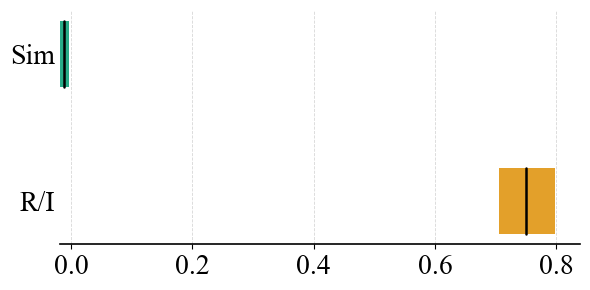

In [59]:
plot_existing_data_interval_estimates(
    aggregate_scores_mean,
    aggregate_score_cis_mean,
    metric='Mean',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='two_systems_mean',
)

In [60]:
aggregate_scores_optimality_gap = {key: value[3:4] for key, value in aggregate_scores.items()}
aggregate_score_cis_optimality_gap = {key: value[:, 3:4]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_optimality_gap: type: {type(aggregate_scores_optimality_gap)}, data: {aggregate_scores_optimality_gap}")
print(f"aggregate_score_cis_optimality_gap: type: {type(aggregate_score_cis_optimality_gap)}, data: {aggregate_score_cis_optimality_gap}")

aggregate_scores_optimality_gap: type: <class 'dict'>, data: {'real world input': array([0.27517361]), 'simulation': array([1.01111111])}
aggregate_score_cis_optimality_gap: type: <class 'dict'>, data: {'real world input': array([[0.23888889],
       [0.31163194]]), 'simulation': array([[1.00381944],
       [1.01840278]])}


legend_map:  {'real world input': 'R/I', 'simulation': 'Sim'}
keys : ['real_world', 'simulation_with_real_world_input']
labels:  ['R/I', 'Sim']


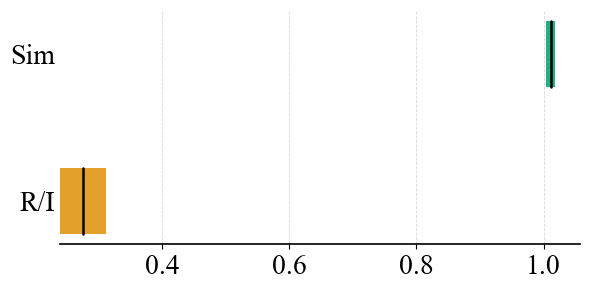

In [61]:
plot_existing_data_interval_estimates(
    aggregate_scores_optimality_gap,
    aggregate_score_cis_optimality_gap,
    metric='Optimality Gap',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='two_systems_optimality_gap',
)

In [64]:
aggregate_scores = {
        "real world system": np.array([0.40972222, 0.41041667, 0.42638889, 0.57361111]), 
        "real world input": np.array([0.07986111, 0.09722222, 0.10208333, 0.89791667]), 
        "simulation": np.array([0.01041667, 0.02152778, 0.02847222, 0.97152778])}
aggregate_score_cis = {
        "real world system": np.array([[0.35763889, 0.38055556, 0.39722222, 0.54375   ],
       [0.44444444, 0.44513889, 0.45625   , 0.60277778]]), 
        "real world input": np.array([[0.07986111, 0.08263889, 0.08819444, 0.88368056],
       [0.11458333, 0.11111111, 0.11631944, 0.91180556]]), 
        "simulation": np.array([[0.01041667, 0.01041667, 0.01736111, 0.96006944],
       [0.04513889, 0.03333333, 0.03993056, 0.98263889]])}

In [65]:
SYSTEM_ORDER = ['real world system', 'real world input', 'simulation']
legend_map = {
    "real world system": "R/W",
    "real world input": "R/I",
    "simulation": "Sim",
}

In [66]:
aggregate_scores_median = {key: value[0:1] for key, value in aggregate_scores.items()}
aggregate_score_cis_median = {key: value[:, 0:1]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_median: type: {type(aggregate_scores_median)}, data: {aggregate_scores_median}")
print(f"aggregate_score_cis_median: type: {type(aggregate_score_cis_median)}, data: {aggregate_score_cis_median}")

aggregate_scores_median: type: <class 'dict'>, data: {'real world system': array([0.40972222]), 'real world input': array([0.07986111]), 'simulation': array([0.01041667])}
aggregate_score_cis_median: type: <class 'dict'>, data: {'real world system': array([[0.35763889],
       [0.44444444]]), 'real world input': array([[0.07986111],
       [0.11458333]]), 'simulation': array([[0.01041667],
       [0.04513889]])}


legend_map:  {'real world system': 'R/W', 'real world input': 'R/I', 'simulation': 'Sim'}
keys : ['real_world', 'simulation_with_real_world_input']
labels:  ['R/W', 'R/I', 'Sim']


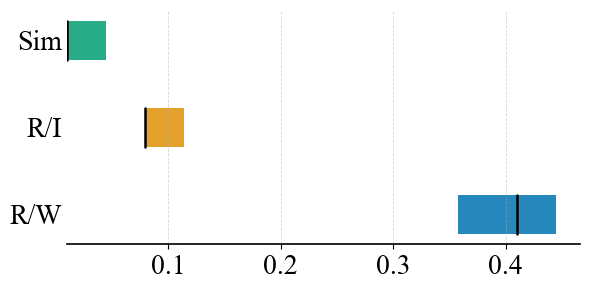

In [67]:
plot_existing_data_interval_estimates(
    aggregate_scores_median,
    aggregate_score_cis_median,
    metric='Median',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='real_world_median',
)

In [68]:
aggregate_scores_iqm = {key: value[1:2] for key, value in aggregate_scores.items()}
aggregate_score_cis_iqm = {key: value[:, 1:2]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_iqm: type: {type(aggregate_scores_iqm)}, data: {aggregate_scores_iqm}")
print(f"aggregate_score_cis_iqm: type: {type(aggregate_score_cis_iqm)}, data: {aggregate_score_cis_iqm}")

aggregate_scores_iqm: type: <class 'dict'>, data: {'real world system': array([0.41041667]), 'real world input': array([0.09722222]), 'simulation': array([0.02152778])}
aggregate_score_cis_iqm: type: <class 'dict'>, data: {'real world system': array([[0.38055556],
       [0.44513889]]), 'real world input': array([[0.08263889],
       [0.11111111]]), 'simulation': array([[0.01041667],
       [0.03333333]])}


legend_map:  {'real world system': 'R/W', 'real world input': 'R/I', 'simulation': 'Sim'}
keys : ['real_world', 'simulation_with_real_world_input']
labels:  ['R/W', 'R/I', 'Sim']


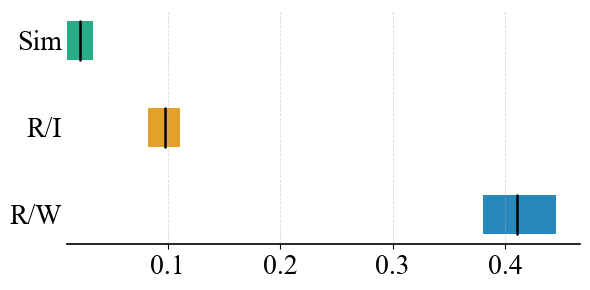

In [69]:
plot_existing_data_interval_estimates(
    aggregate_scores_iqm,
    aggregate_score_cis_iqm,
    metric='IQM',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='real_world_iqm',
)

In [70]:
aggregate_scores_mean = {key: value[2:3] for key, value in aggregate_scores.items()}
aggregate_score_cis_mean = {key: value[:, 2:3]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_mean: type: {type(aggregate_scores_mean)}, data: {aggregate_scores_mean}")
print(f"aggregate_score_cis_mean: type: {type(aggregate_score_cis_mean)}, data: {aggregate_score_cis_mean}")

aggregate_scores_mean: type: <class 'dict'>, data: {'real world system': array([0.42638889]), 'real world input': array([0.10208333]), 'simulation': array([0.02847222])}
aggregate_score_cis_mean: type: <class 'dict'>, data: {'real world system': array([[0.39722222],
       [0.45625   ]]), 'real world input': array([[0.08819444],
       [0.11631944]]), 'simulation': array([[0.01736111],
       [0.03993056]])}


legend_map:  {'real world system': 'R/W', 'real world input': 'R/I', 'simulation': 'Sim'}
keys : ['real_world', 'simulation_with_real_world_input']
labels:  ['R/W', 'R/I', 'Sim']


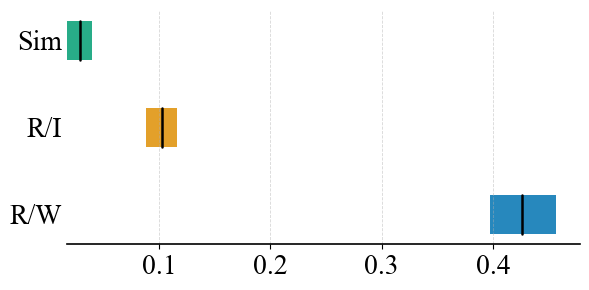

In [71]:
plot_existing_data_interval_estimates(
    aggregate_scores_mean,
    aggregate_score_cis_mean,
    metric='Mean',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='real_world_mean',
)

In [72]:
aggregate_scores_optimality_gap = {key: value[3:4] for key, value in aggregate_scores.items()}
aggregate_score_cis_optimality_gap = {key: value[:, 3:4]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_optimality_gap: type: {type(aggregate_scores_optimality_gap)}, data: {aggregate_scores_optimality_gap}")
print(f"aggregate_score_cis_optimality_gap: type: {type(aggregate_score_cis_optimality_gap)}, data: {aggregate_score_cis_optimality_gap}")

aggregate_scores_optimality_gap: type: <class 'dict'>, data: {'real world system': array([0.57361111]), 'real world input': array([0.89791667]), 'simulation': array([0.97152778])}
aggregate_score_cis_optimality_gap: type: <class 'dict'>, data: {'real world system': array([[0.54375   ],
       [0.60277778]]), 'real world input': array([[0.88368056],
       [0.91180556]]), 'simulation': array([[0.96006944],
       [0.98263889]])}


legend_map:  {'real world system': 'R/W', 'real world input': 'R/I', 'simulation': 'Sim'}
keys : ['real_world', 'simulation_with_real_world_input']
labels:  ['R/W', 'R/I', 'Sim']


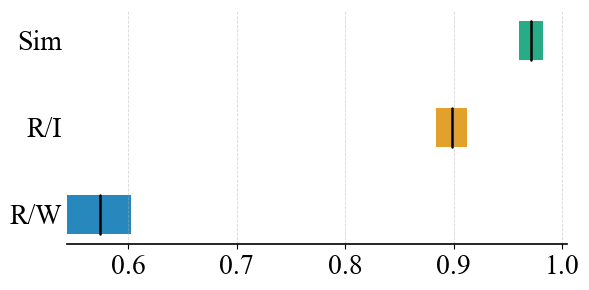

In [73]:
plot_existing_data_interval_estimates(
    aggregate_scores_optimality_gap,
    aggregate_score_cis_optimality_gap,
    metric='Optimality Gap',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='real_world_optimality_gap',
)

In [165]:
import cv2

from matplotlib.colors import ListedColormap

In [214]:
def compute_diff(a, b):
    a = np.asarray(a)
    b = np.asarray(b)

    # Ensure same shape
    if a.shape != b.shape:
        raise ValueError(f"Shape mismatch: {a.shape} vs {b.shape}")

    diff = np.abs(a.astype(np.float32) - b.astype(np.float32))
    return diff

In [204]:
def compute_diff_image(a, b):
    a = cv2.cvtColor(a, cv2.COLOR_RGB2GRAY)
    b = cv2.cvtColor(b, cv2.COLOR_RGB2GRAY)
    a = np.asarray(a)
    b = np.asarray(b)

    # Ensure same shape
    if a.shape != b.shape:
        raise ValueError(f"Shape mismatch: {a.shape} vs {b.shape}")

    diff = np.abs(a.astype(np.float32) - b.astype(np.float32))
    return diff

In [192]:
def percent_pixels_different(a, b):
    a = np.asarray(a)
    b = np.asarray(b)

    if a.shape != b.shape:
        raise ValueError(f"Shape mismatch: {a.shape} vs {b.shape}")

    # Pixel-by-pixel comparison
    diff_mask = a != b

    # For RGB images, collapse channel differences
    if diff_mask.ndim == 3:
        diff_mask = diff_mask.any(axis=2)

    # Percentage of pixels that differ
    return diff_mask.mean() * 100

In [193]:
def show_single_color_heatmap(diff, color="red", threshold=0, percent=0):
    mask = (diff > threshold).astype(np.uint8)
    cmap = ListedColormap(["black", color])

    plt.figure(figsize=(8, 6))
    plt.imshow(mask, cmap=cmap)
    plt.title(f"Pixel Difference percentage: {percent:.2f}%")
    plt.axis("off")
    plt.savefig(f'difference.pdf', dpi=800, bbox_inches='tight')
    plt.show()

In [194]:
def plot_heatmap(diff):
    plt.figure(figsize=(8, 6))
    plt.imshow(diff, cmap="hot")
    plt.colorbar(label="Difference Intensity")
    # plt.title("Difference Heatmap")
    plt.axis("off")
    plt.savefig(f'heatmap.pdf', dpi=800, bbox_inches='tight')
    plt.show()

In [195]:
def plot_3d_surface(diff):
    h, w = diff.shape
    X, Y = np.meshgrid(np.arange(w), np.arange(h))

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(X, Y, diff, cmap="viridis", linewidth=0, antialiased=False)
    ax.set_title("3D Surface of Array Difference")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Difference")
    plt.savefig(f'3d_surface.pdf', dpi=800, bbox_inches='tight')
    plt.show()

In [196]:
def plot_3d_surface_no_color(diff):
    h, w = diff.shape
    X, Y = np.meshgrid(np.arange(w), np.arange(h))

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(
        X, Y, diff,
        cmap=None,
        color='lightgray',     # uniform color
        edgecolor='none'       # remove grid lines
    )

    ax.set_title("3D Surface of Array Difference (No Colors)")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Difference")

    plt.show()

(480, 640, 3)


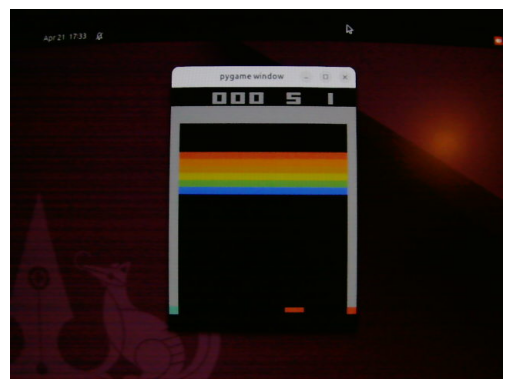

In [197]:
img = np.load("./images/original_file.npy")   # shape (H, W, 3)
print(img.shape)

plt.imshow(img[:, :, [2, 1, 0]].astype(np.uint8))
plt.axis("off")
plt.savefig(f'original_file.pdf', bbox_inches='tight')
plt.show()


(320, 245, 3)


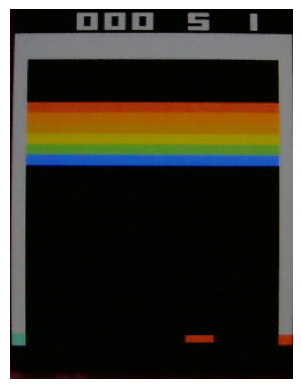

In [198]:
img = np.load("./images/cropped_file.npy")   # shape (H, W, 3)
print(img.shape)

plt.imshow(img[:, :, [2, 1, 0]].astype(np.uint8))
plt.axis("off")
plt.savefig(f'cropped_file.pdf', dpi=800, bbox_inches='tight')
plt.show()


(210, 160, 3)


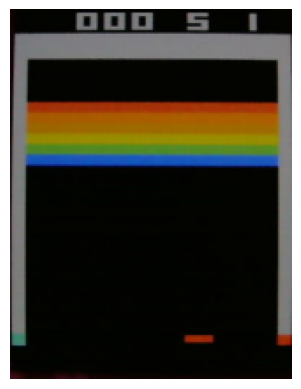

In [199]:
img1 = cv2.resize(img, (160, 210), interpolation=cv2.INTER_AREA)
img1 = img1[:, :, [2, 1, 0]]
# plt.imshow(img1[:, :, [2, 1, 0]].astype(np.uint8))
plt.imshow(img1.astype(np.uint8))
print(img3.shape)
plt.axis("off")
plt.savefig(f'cropped_210x160.pdf', dpi=800, bbox_inches='tight')
plt.show()

(210, 160, 3)


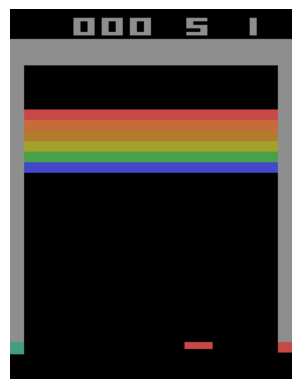

In [200]:
img2 = np.load("./images/env_obs_file.npy")   # shape (H, W, 3)
print(img2.shape)

plt.imshow(img2.astype(np.uint8))
plt.axis("off")
plt.savefig(f'env_obs_file.pdf', dpi=800, bbox_inches='tight')
plt.show()


In [205]:
diff = compute_diff_image(img1, img2)

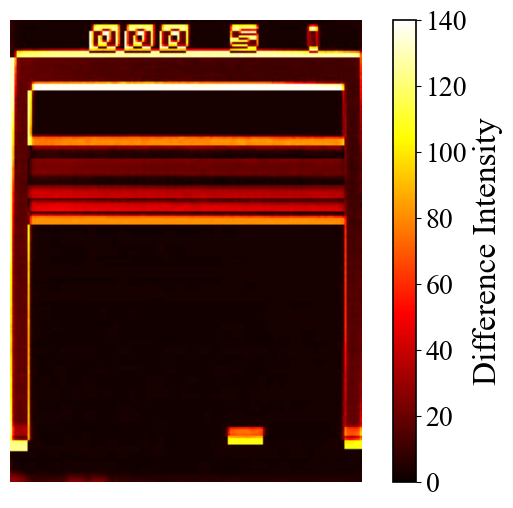

In [206]:
plot_heatmap(diff)

(320, 245, 3)


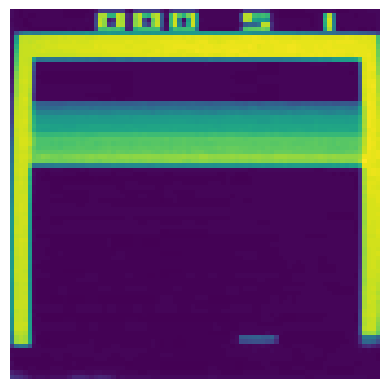

In [207]:
img1 = np.load("./images/preprocessed_file.npy")   # shape (H, W, 3)
print(img.shape)

plt.imshow(img1.astype(np.uint8))
plt.axis("off")
# plt.savefig(f'preprocessed_file.pdf', dpi=800, bbox_inches='tight')
plt.show()

(84, 84)


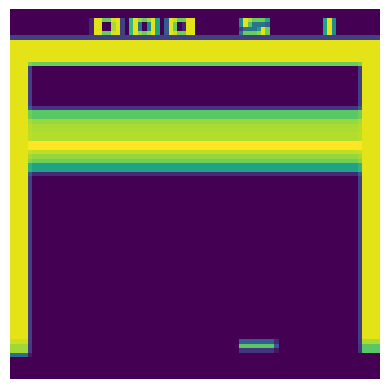

In [208]:
img2 = np.load("./images/obs_resized_file.npy")   # shape (H, W, 3)
print(img2.shape)

plt.imshow(img2.astype(np.uint8))
plt.axis("off")
plt.savefig(f'obs_resized_file.pdf', dpi=800, bbox_inches='tight')
plt.show()


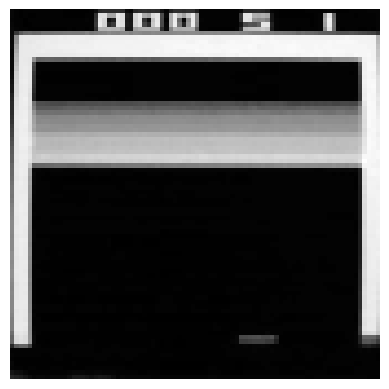

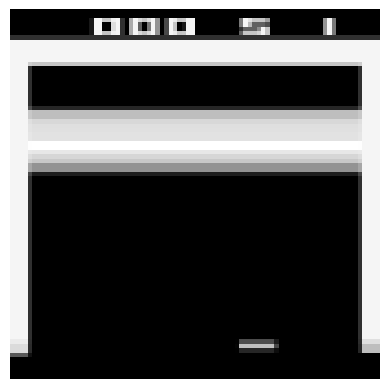

In [209]:
plt.imshow(img1.astype(np.uint8), cmap="gray")
plt.axis("off")
plt.savefig(f'preprocessed_file.pdf', dpi=800, bbox_inches='tight')
plt.show()
plt.imshow(img2.astype(np.uint8), cmap="gray")
plt.axis("off")
plt.savefig(f'obs_resized_file.pdf', dpi=800, bbox_inches='tight')
plt.show()

In [210]:
from mpl_toolkits.mplot3d import Axes3D

In [211]:
percent = percent_pixels_different(img1, img2)
print("Percentage of pixels different:", percent)

Percentage of pixels different: 99.95748299319727


In [215]:
diff = compute_diff(img1, img2)

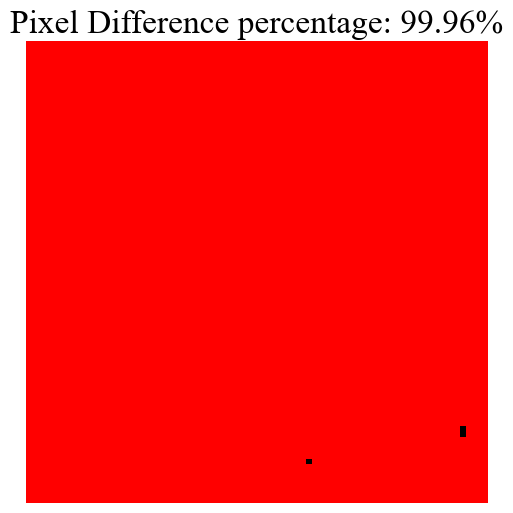

In [216]:
show_single_color_heatmap(diff, color="red", threshold=0, percent=percent)

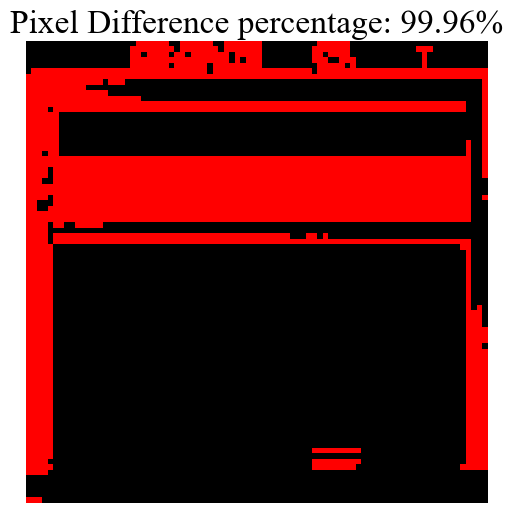

In [219]:
show_single_color_heatmap(diff, color="red", threshold=15, percent=percent)

In [139]:
diff_flippedd = np.flipud(diff)

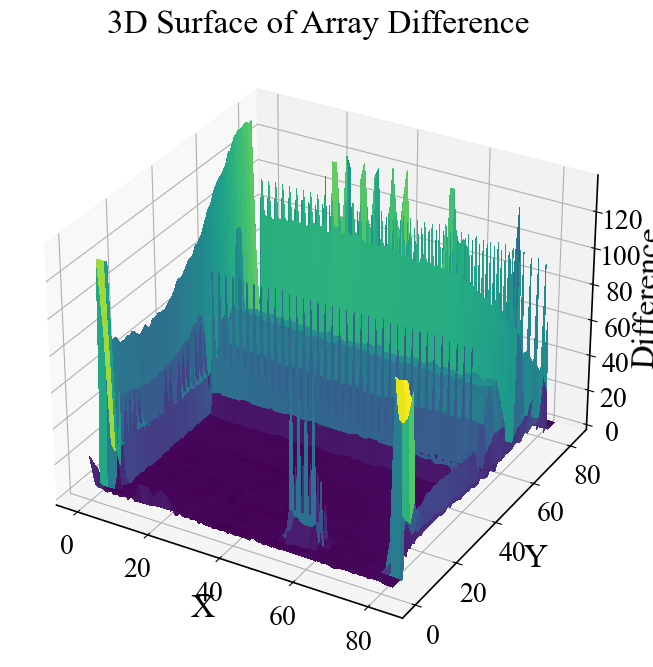

In [140]:
plot_3d_surface(diff_flippedd)

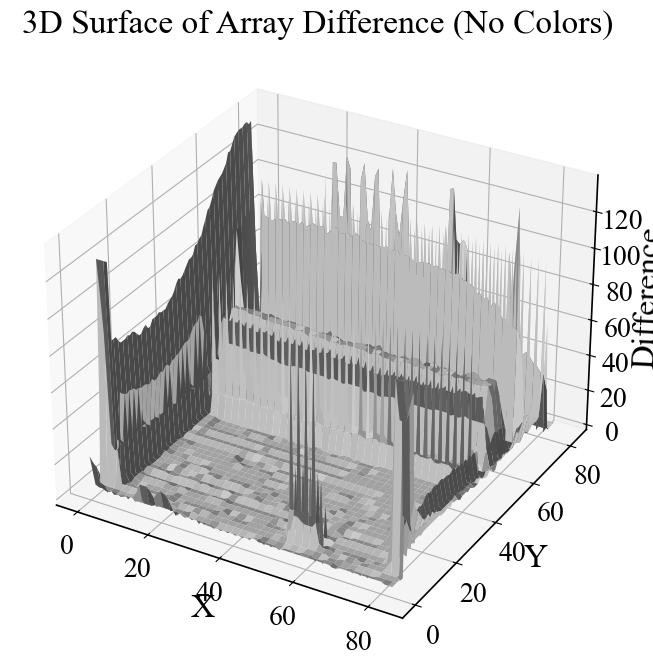

In [142]:
plot_3d_surface_no_color(diff_flippedd)

In [ ]:
diff_flippedr = np.fliplr(diff)

In [ ]:
plot_3d_surface(diff_flippedr)

In [ ]:
plot_3d_surface(diff)